# 03 - Analisis de efectos secundarios por componente

Este notebook esta reservado para el analisis final del enfoque de efectos secundarios por componente.

Preguntas posibles:
- que efectos secundarios aparecen con mayor frecuencia por componente;
- si ciertas combinaciones muestran efectos recurrentes;
- que relaciones destacan entre principios activos y efectos adversos.

In [21]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# Resolver raíz del proyecto y exponer src
current = Path.cwd()
while current != current.parent:
    if (current / "pyproject.toml").exists() or (current / "requirements.txt").exists():
        project_root = current
        break
    current = current.parent
else:
    project_root = Path.cwd()

sys.path.insert(0, str(project_root / "src"))

from enfoque3.load_data import load_data
from enfoque3.validation import validate_data
from enfoque3.cleaning import clean_data
from enfoque3.transform import transform_data
from enfoque3.analysis import component_vs_effects, normalize

# Cargar y validar datos
df = load_data(project_root / "data" / "raw" / "Medicine_Details.csv")
validate_data(df)

print("✓ Setup listo: imports desde src/enfoque3")
print(f"  Dataset: {df.shape[0]} filas × {df.shape[1]} columnas")

✓ Nota: Este notebook asume que ejecutaste los notebooks 01 y 02
  Se recomienda ejecutar en orden:
  1. 01_eda_efectos_secundarios_componentes.ipynb
  2. 02_limpieza_transformacion_efectos_secundarios_componentes.ipynb
  3. 03_analisis_efectos_secundarios_componentes.ipynb (este)


## Preparación de Datos

Procesamiento y tablas necesarias para el análisis (consolida funciones + transformación).


In [22]:
# Preparación con el pipeline de src/enfoque3
df_clean = clean_data(df)
df_exploded = transform_data(df_clean)

crosstab_frecuencias = component_vs_effects(df_exploded)
crosstab_proporciones = normalize(crosstab_frecuencias) * 100
frecuencias_componentes = crosstab_frecuencias.sum(axis=1).sort_values(ascending=False)
frecuencias_efectos = crosstab_frecuencias.sum(axis=0).sort_values(ascending=False)

print(f"✓ Datos listos:\n  Medicamentos: {len(df_clean)} | Expandidos: {len(df_exploded)}")
print(
    f"  Componentes: {df_exploded['componentes'].nunique()} | "
    f"Efectos: {df_exploded['efectos_secundarios'].nunique()}"
)

✓ Datos listos:
  Medicamentos: 11825 | Expandidos: 124225
  Componentes: 3067 | Efectos: 762


## Visualizaciones

### 1. Heatmap de Componentes × Efectos

Visualizamos la intensidad de la relación entre componentes y efectos usando un heatmap. Los colores más oscuros indican frecuencias más altas.


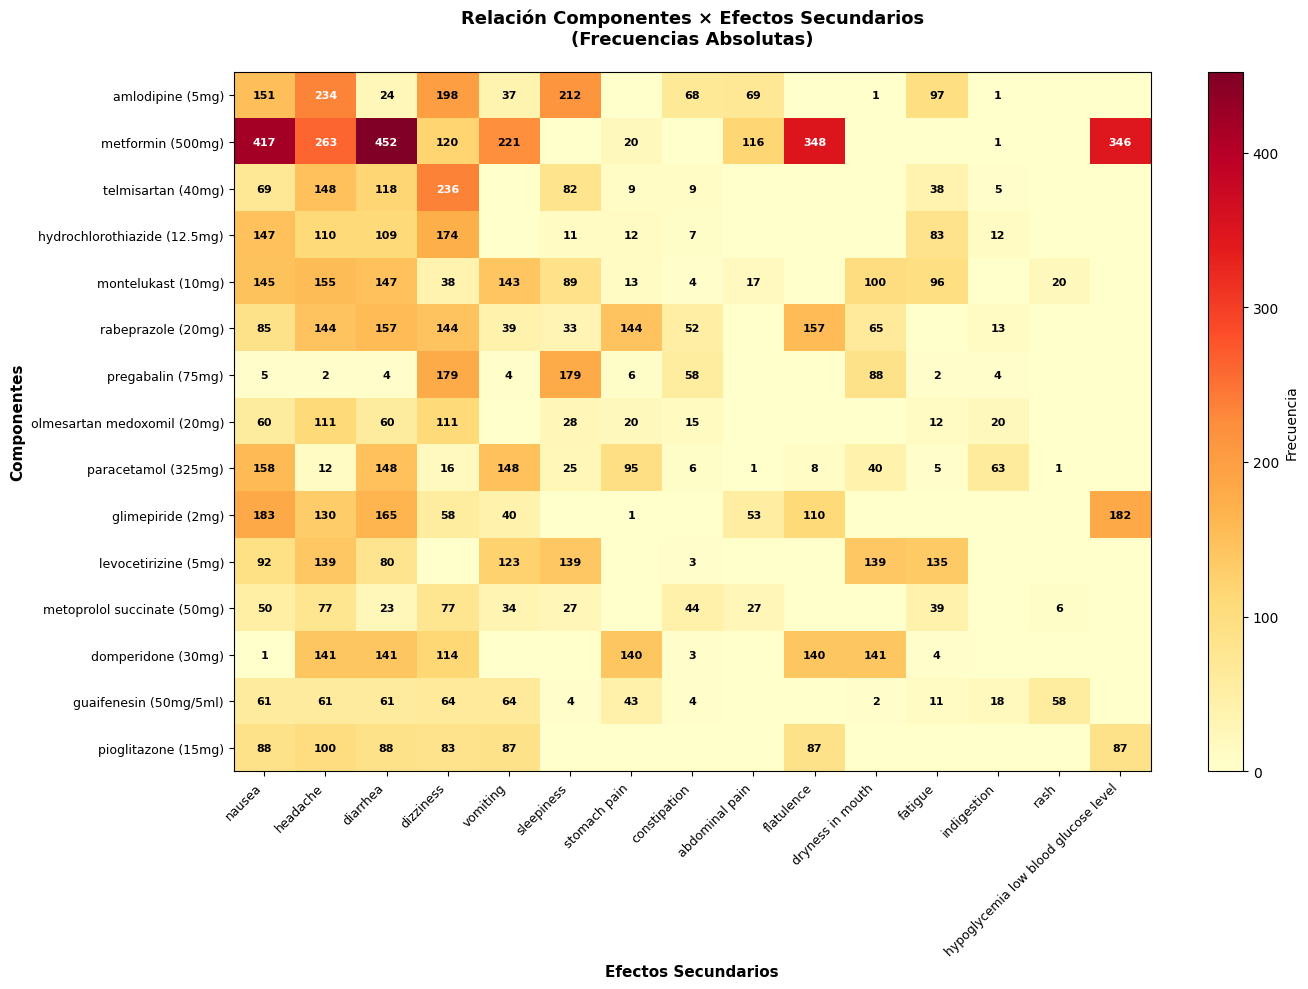

✓ Heatmap guardado como 'heatmap_componentes_efectos.png'


In [23]:
# Limitar tamaño para mejor visualización (top 15 componentes y efectos)
top_n_componentes = 15
top_n_efectos = 15

top_comp = frecuencias_componentes.head(top_n_componentes).index
top_eff = frecuencias_efectos.head(top_n_efectos).index

crosstab_top = crosstab_frecuencias.loc[top_comp, top_eff]

# Crear figura con heatmap
fig, ax = plt.subplots(figsize=(14, 10))

# Normalizar datos para el colormap
vmin, vmax = crosstab_top.min().min(), crosstab_top.max().max()
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.YlOrRd

# Dibujar el heatmap manualmente
im = ax.imshow(crosstab_top.values, cmap=cmap, norm=norm, aspect='auto')

# Etiquetas
ax.set_xticks(range(len(top_eff)))
ax.set_yticks(range(len(top_comp)))
ax.set_xticklabels(top_eff, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(top_comp, fontsize=9)

# Agregar valores en las celdas
for i in range(len(top_comp)):
    for j in range(len(top_eff)):
        valor = crosstab_top.values[i, j]
        if valor > 0:
            color_texto = 'white' if valor > (vmax - vmin) / 2 + vmin else 'black'
            ax.text(j, i, f'{int(valor)}', ha='center', va='center', 
                   color=color_texto, fontsize=8, weight='bold')

# Colorbar
cbar = plt.colorbar(im, ax=ax, label='Frecuencia')

ax.set_xlabel('Efectos Secundarios', fontsize=11, weight='bold')
ax.set_ylabel('Componentes', fontsize=11, weight='bold')
ax.set_title('Relación Componentes × Efectos Secundarios\n(Frecuencias Absolutas)', 
            fontsize=13, weight='bold', pad=20)

plt.tight_layout()
plt.savefig('heatmap_componentes_efectos.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Heatmap guardado como 'heatmap_componentes_efectos.png'")


### 2. Gráfico de Barras: Efectos por Componente

Mostramos los efectos más comunes para un componente específico. Los datos están normalizados como porcentajes.


Analizando el componente más frecuente: 'amlodipine (5mg)'
Frecuencia total: 2849 medicamentos



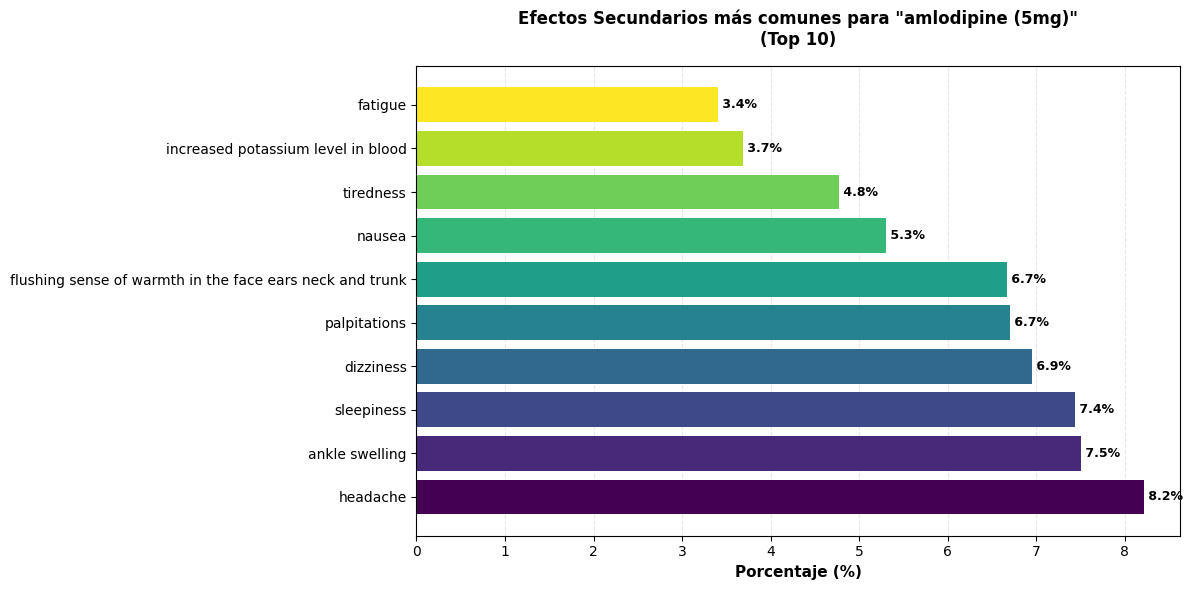


✓ Efectos para 'amlodipine (5mg)':
efectos
headache                                                    8.213408
ankle swelling                                              7.511408
sleepiness                                                  7.441207
dizziness                                                   6.949807
palpitations                                                6.704107
flushing sense of warmth in the face ears neck and trunk    6.669007
nausea                                                      5.300105
tiredness                                                   4.773605
increased potassium level in blood                          3.685504
fatigue                                                     3.404703
Name: amlodipine (5mg), dtype: float64


In [24]:
# Función para visualizar efectos de un componente
def graficar_efectos_componente(componente, n_top=10, usar_porcentajes=True):
    """
    Grafica los efectos más comunes para un componente específico.
    
    Parameters:
    -----------
    componente : str
        Nombre del componente a analizar
    n_top : int
        Número de efectos principales a mostrar
    usar_porcentajes : bool
        Si True usa proporciones, si False usa frecuencias
    """
    if componente not in crosstab_frecuencias.index:
        print(f"❌ Componente '{componente}' no encontrado.")
        return
    
    # Seleccionar datos
    if usar_porcentajes:
        datos = crosstab_proporciones.loc[componente].sort_values(ascending=False).head(n_top)
        y_label = "Porcentaje (%)"
        unidad = "%"
    else:
        datos = crosstab_frecuencias.loc[componente].sort_values(ascending=False).head(n_top)
        y_label = "Frecuencia (cantidad)"
        unidad = ""
    
    # Crear gráfico
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colores = plt.cm.viridis(np.linspace(0, 1, len(datos)))
    barras = ax.barh(range(len(datos)), datos.values, color=colores)
    
    # Personalización
    ax.set_yticks(range(len(datos)))
    ax.set_yticklabels(datos.index, fontsize=10)
    ax.set_xlabel(y_label, fontsize=11, weight='bold')
    ax.set_title(f'Efectos Secundarios más comunes para "{componente}"\n(Top {n_top})', 
                fontsize=12, weight='bold', pad=15)
    
    # Agregar valores en las barras
    for i, (idx, val) in enumerate(datos.items()):
        ax.text(val, i, f' {val:.1f}{unidad}', va='center', fontsize=9, weight='bold')
    
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Efectos para '{componente}':")
    print(datos)

# Seleccionar el componente más frecuente como ejemplo
componente_ejemplo = frecuencias_componentes.index[0]
print(f"Analizando el componente más frecuente: '{componente_ejemplo}'")
print(f"Frecuencia total: {frecuencias_componentes.iloc[0]} medicamentos\n")

graficar_efectos_componente(componente_ejemplo, n_top=10, usar_porcentajes=True)


### 3. Gráfico de Barras: Efectos Secundarios Más Comunes (Global)

Mostramos los efectos secundarios más frecuentes en toda la base de datos, independientemente del componente.


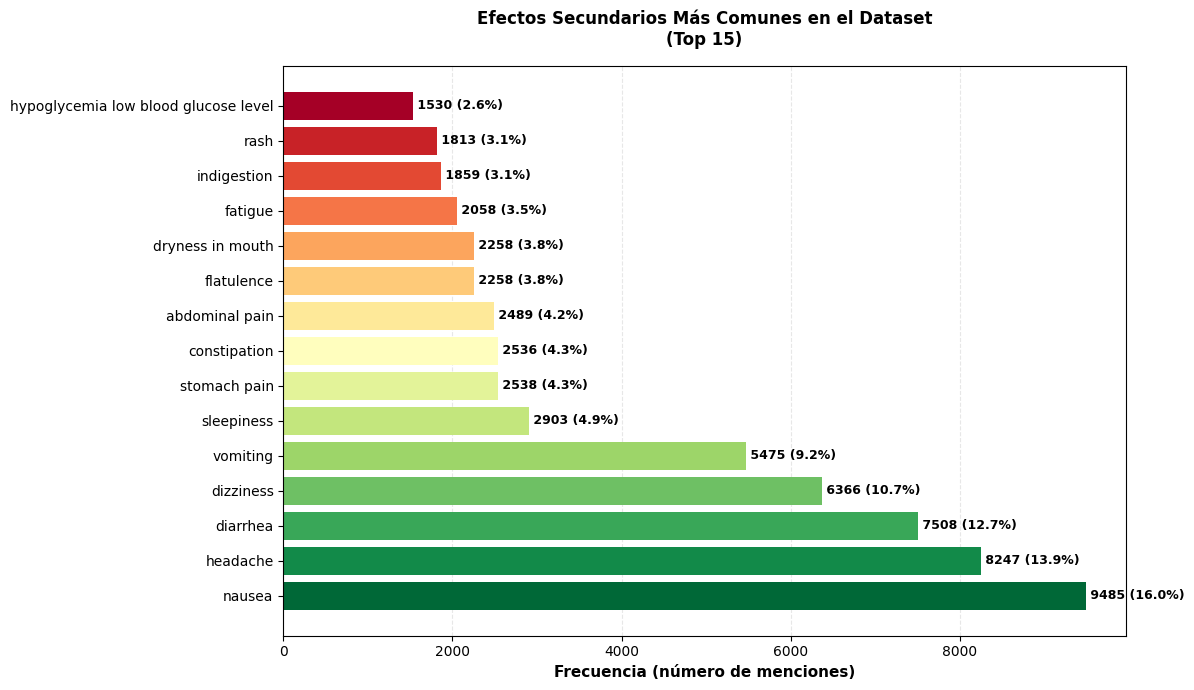

✓ Gráfico guardado como 'efectos_globales.png'


In [25]:
# Gráfico de los efectos más comunes globalmente
top_efectos = frecuencias_efectos.head(15)

fig, ax = plt.subplots(figsize=(12, 7))

colores = plt.cm.RdYlGn_r(np.linspace(0, 1, len(top_efectos)))
barras = ax.barh(range(len(top_efectos)), top_efectos.values, color=colores)

ax.set_yticks(range(len(top_efectos)))
ax.set_yticklabels(top_efectos.index, fontsize=10)
ax.set_xlabel('Frecuencia (número de menciones)', fontsize=11, weight='bold')
ax.set_title('Efectos Secundarios Más Comunes en el Dataset\n(Top 15)', 
            fontsize=12, weight='bold', pad=15)

# Agregar valores con porcentaje
total_menciones = top_efectos.sum()
for i, (idx, val) in enumerate(top_efectos.items()):
    porcentaje = (val / total_menciones) * 100
    ax.text(val, i, f' {int(val)} ({porcentaje:.1f}%)', va='center', fontsize=9, weight='bold')

ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('efectos_globales.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado como 'efectos_globales.png'")


## Análisis de Insights

Identificamos patrones clave: componentes riesgosos, efectos más comunes y relaciones importantes.


In [26]:
print("="*70)
print("📊 ANÁLISIS DE INSIGHTS: COMPONENTES Y EFECTOS SECUNDARIOS")
print("="*70)

# 1. Top efectos por componente (riesgo relativo)
print("\n1️⃣  COMPONENTES MÁS RIESGOSOS")
print("-" * 70)
print("(Componentes con el mayor rango de efectos diferentes)\n")

riesgo_relativo = (crosstab_frecuencias > 0).sum(axis=1).sort_values(ascending=False).head(10)
for i, (comp, cantidad) in enumerate(riesgo_relativo.items(), 1):
    freq = frecuencias_componentes[comp]
    print(f"{i:2d}. {comp:30s} | Efectos diversos: {int(cantidad):3d} | Frecuencia: {int(freq):4d}")

# 2. Componentes con más efectos secundarios totales
print("\n2️⃣  COMPONENTES MÁS FRECUENTES EN EL DATASET")
print("-" * 70)
for i, (comp, freq) in enumerate(frecuencias_componentes.head(10).items(), 1):
    efectos_unicos = (crosstab_frecuencias.loc[comp] > 0).sum()
    print(f"{i:2d}. {comp:30s} | Apariciones: {int(freq):5d} | Efectos: {int(efectos_unicos):3d}")

# 3. Efectos más frecuentes por componente
print("\n3️⃣  RELACIONES COMPONENTE → EFECTO MÁS FUERTES")
print("-" * 70)
print("(Top 10 combinaciones más frecuentes)\n")

top_combinaciones = (
    df_exploded.groupby(["componentes", "efectos_secundarios"]).size()
    .sort_values(ascending=False)
    .head(10)
)

for i, ((comp, efecto), freq) in enumerate(top_combinaciones.items(), 1):
    pct = (freq / frecuencias_componentes[comp] * 100) if comp in frecuencias_componentes else 0
    print(f"{i:2d}. {comp:25s} → {efecto:30s} | {int(freq):4d} casos ({pct:.1f}%)")

# 4. Efectos más comunes globalmente
print("\n4️⃣  EFECTOS SECUNDARIOS MÁS COMUNES (GLOBAL)")
print("-" * 70)
for i, (efecto, freq) in enumerate(frecuencias_efectos.head(10).items(), 1):
    componentes_con_efecto = (crosstab_frecuencias[efecto] > 0).sum()
    pct_global = (freq / len(df_exploded) * 100)
    print(f"{i:2d}. {efecto:40s} | {int(freq):5d} ({pct_global:.1f}%) | En {int(componentes_con_efecto)} componentes")

# 5. Análisis de componentes específicos
print("\n5️⃣  ANÁLISIS DETALLADO DE COMPONENTES PRINCIPALES")
print("-" * 70)

for comp in frecuencias_componentes.head(5).index:
    print(f"\n📌 {comp.upper()}")
    print(f"   Frecuencia: {frecuencias_componentes[comp]} medicamentos")

    efectos_principales = crosstab_frecuencias.loc[comp].nlargest(3)
    print("   Efectos principales:")
    for efecto, freq in efectos_principales.items():
        pct = (freq / frecuencias_componentes[comp] * 100)
        print(f"      • {efecto}: {int(freq)} ({pct:.1f}%)")

print("\n" + "="*70)
print("✓ Análisis completado")
print("="*70)

📊 ANÁLISIS DE INSIGHTS: COMPONENTES Y EFECTOS SECUNDARIOS

1️⃣  COMPONENTES MÁS RIESGOSOS
----------------------------------------------------------------------
(Componentes con el mayor rango de efectos diferentes)

 1. amlodipine (5mg)               | Efectos diversos:  58 | Frecuencia: 2849
 2. telmisartan (40mg)             | Efectos diversos:  55 | Frecuencia: 2117
 3. hydrochlorothiazide (12.5mg)   | Efectos diversos:  49 | Frecuencia: 1624
 4. montelukast (10mg)             | Efectos diversos:  48 | Frecuencia: 1507
 5. tenofovir disoproxil fumarate (300mg) | Efectos diversos:  45 | Frecuencia:  332
 6. olmesartan medoxomil (20mg)    | Efectos diversos:  45 | Frecuencia: 1160
 7. paracetamol (325mg)            | Efectos diversos:  44 | Frecuencia: 1118
 8. amlodipine (2.5mg)             | Efectos diversos:  44 | Frecuencia:  386
 9. efavirenz (600mg)              | Efectos diversos:  43 | Frecuencia:  148
10. nebivolol (5mg)                | Efectos diversos:  43 | Frecuencia:  

## Explicación de Gráficos e Insights

### 📊 ¿Qué significa cada gráfico?

**1. Heatmap (Matriz de Colores)**
- **Qué muestra**: La frecuencia de cada combinación componente-efecto
- **Interpretación**: 
  - Colores más oscuros = relaciones más fuertes (más medicamentos presentan esa combinación)
  - Espacios en blanco = esa combinación no existe en los datos
- **Uso**: Identificar patrones visuales rápidamente y detectar componentes/efectos que "viajan juntos"

**2. Gráfico de Barras (Efectos por Componente)**
- **Qué muestra**: Los efectos secundarios más comunes para UN componente específico
- **Interpretación**: El tamaño de la barra indica qué tan frecuente es ese efecto entre medicamentos que contienen ese componente
- **Uso**: Evaluar el perfil de seguridad de un componente individual

**3. Gráfico de Barras Global (Efectos Más Comunes)**
- **Qué muestra**: Cuáles son los efectos secundarios más mencionados en toda la base de datos
- **Interpretación**: Muestra qué problemas de salud son más prevalentes en los medicamentos estudiados
- **Uso**: Identificar los efectos adversos que requieren más atención clínica

### 💡 ¿Qué insights se pueden obtener?

**Patrones Clave:**
1. **Componentes riesgosos**: Aquellos que aparecen con muchos efectos secundarios diferentes
2. **Efectos comunes**: Los problemas que más medicamentos causan
3. **Relaciones fuertes**: Combinaciones componente-efecto que aparecen frecuentemente juntas
4. **Alternativas más seguras**: Componentes con menos efectos o efectos menos graves

**Preguntas que podemos responder:**
- ¿Cuál es el componente más peligroso? → El con mayor diversidad o frecuencia de efectos
- ¿Cuál es el efecto más común? → Se ve claramente en los gráficos de barras
- ¿Hay componentes más seguros? → Aquellos con pocos efectos y frecuencias bajas
- ¿Hay combinaciones de componentes que aumentan riesgo? → Se ve en el heatmap y en el crosstab

**Limitaciones a considerar:**
- Los datos muestran correlación, no causalidad directa
- El número de menciones depende del número de medicamentos en la BD
- Los efectos raros pueden no estar bien representados
- La severidad del efecto no está considerada (solo frecuencia)

